# Support Vector Regression

In [56]:
## Imports and helper functions
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from scipy.optimize import minimize

def get_simple():
    np.random.seed(7)
    X = np.linspace(-3, 3, 11)
    y = np.sin(X) + 0.2 * np.random.randn(11)
    return X, y

## Introduction to Support Vector Regression

**Support Vector Regression (SVR)** extends the SVM idea from Exercise 3 to *regression* problems. Instead of separating two classes with a maximum margin, SVR fits a **tube of width $2\varepsilon$** around the unknown target function:

- Predictions that land **inside the tube** incur no loss — small errors are simply ignored.
- Predictions that fall **outside the tube** are penalised linearly with how far they are from the tube boundary.

This is captured by the **$\varepsilon$-insensitive loss**:
$$E_\varepsilon(y, t) = \max(0,\; |y - t| - \varepsilon).$$
The flat region around zero makes the solution **sparse**: only the training points whose predictions sit on or outside the tube become *support vectors* — every other training point is forgotten after fitting.

**Connections to previous exercises.**
- Like SVM (Ex. 3), SVR is solved in its **dual form** with `scipy.optimize.minimize`, has box constraints $0 \leq a_n \leq C$ on the dual variables, and uses the kernel trick directly.
- Unlike SVM, the targets are real-valued ($t_n \in \mathbb{R}$) and we need **two** sets of dual variables: $a_n$ for points lying *above* the tube and $\hat{a}_n$ for points lying *below*. The KKT conditions ensure that at most one of $a_n, \hat{a}_n$ is non-zero for any given training point.

**This notebook covers:**
1. The $\varepsilon$-insensitive loss and what it looks like
2. The dual SVR problem and its rewrite in matrix form
3. Implementing the SVR by reusing the `scipy.optimize.minimize` recipe from Ex. 3
4. Training and visualising the $\varepsilon$-tube and the support vectors
5. Playing with the hyperparameters $\varepsilon$ and $C$

## The $\varepsilon$-Insensitive Loss

Before deriving the dual problem, let's see what the loss function looks like. The classical squared loss penalises *every* deviation, including tiny ones. The $\varepsilon$-insensitive loss instead has a **flat zero region** of width $2\varepsilon$ — this is the key reason SVR produces sparse solutions.

$$E_\varepsilon(y, t) = \begin{cases} 0 & \text{if } |y - t| \leq \varepsilon \\ |y - t| - \varepsilon & \text{otherwise} \end{cases}$$

The plot below compares this loss to the squared loss.

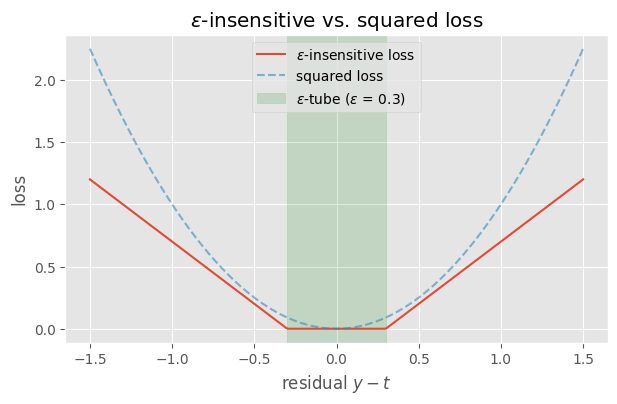

In [57]:
# Visualize the epsilon-insensitive loss vs. squared loss
eps = 0.3
r = np.linspace(-1.5, 1.5, 300)

eps_loss = np.maximum(0, np.abs(r) - eps)
sq_loss  = r**2

plt.figure(figsize=(7, 4))
plt.plot(r, eps_loss, label=r'$\varepsilon$-insensitive loss')
plt.plot(r, sq_loss, '--', alpha=0.6, label='squared loss')
plt.axvspan(-eps, eps, alpha=0.15, color='green', label=rf'$\varepsilon$-tube ($\varepsilon$ = {eps})')
plt.xlabel(r'residual $y - t$')
plt.ylabel('loss')
plt.legend()
plt.title(r'$\varepsilon$-insensitive vs. squared loss')
plt.show()

## Training SVR via Constrained Optimization

We assume training inputs $\mathbf{X} \in \mathbb{R}^{N \times D}$ and *real-valued* targets $\mathbf{t} \in \mathbb{R}^N$. As in Exercise 3, we work with the Gram matrix $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$.

#### Symbol glossary

| Symbol | Meaning |
|---|---|
| $\mathbf{a}, \hat{\mathbf{a}} \in \mathbb{R}^N$ | Dual variables — one for the upper, one for the lower side of the tube. |
| $\mathbf{d} = \mathbf{a} - \hat{\mathbf{a}}$ | The "signed" weight vector that actually appears in predictions. |
| $C > 0$ | Regularization parameter; upper bound on each $a_n$ and $\hat{a}_n$. |
| $\varepsilon > 0$ | Tube half-width — predictions within $\pm \varepsilon$ of the target incur no loss. |
| $\mathcal{S}$ | Support vectors: indices with $a_n > 0$ or $\hat{a}_n > 0$. |
| $\mathcal{M}$ | Margin support vectors: indices with $0 < a_n < C$ (or $0 < \hat{a}_n < C$). |

#### The dual SVR problem (Bishop Sec. 7.1.4)

The dual objective is

$$\widetilde{L}(\mathbf{a}, \hat{\mathbf{a}}) = -\tfrac{1}{2}\sum_{n=1}^N\sum_{m=1}^N (a_n - \hat{a}_n)(a_m - \hat{a}_m)\,k(\mathbf{x}_n, \mathbf{x}_m) - \varepsilon\sum_{n=1}^N (a_n + \hat{a}_n) + \sum_{n=1}^N (a_n - \hat{a}_n)\,t_n,$$

which we **maximize** subject to
$$0 \leq a_n \leq C, \qquad 0 \leq \hat{a}_n \leq C, \qquad \sum_{n=1}^N (a_n - \hat{a}_n) = 0.$$

The equality constraint comes from setting the derivative w.r.t. the bias $b$ to zero in the primal Lagrangian.

#### Matrix form

Let $\mathbf{d} = \mathbf{a} - \hat{\mathbf{a}}$ and $\mathbf{1}$ a vector of ones. The dual objective is

$$\widetilde{L}(\mathbf{a}, \hat{\mathbf{a}}) = -\tfrac{1}{2}\,\mathbf{d}^\top \mathbf{K}\, \mathbf{d} - \varepsilon\,\mathbf{1}^\top (\mathbf{a} + \hat{\mathbf{a}}) + \mathbf{t}^\top \mathbf{d}.$$

Expanding the quadratic part using $\mathbf{d} = \mathbf{a} - \hat{\mathbf{a}}$ gives the form we will plug into `scipy.optimize.minimize`:
$$\mathbf{d}^\top \mathbf{K}\, \mathbf{d} = \mathbf{a}^\top \mathbf{K}\, \mathbf{a} - 2\,\mathbf{a}^\top \mathbf{K}\, \hat{\mathbf{a}} + \hat{\mathbf{a}}^\top \mathbf{K}\, \hat{\mathbf{a}}.$$

#### Bias and prediction

For any training point with $0 < a_n < C$ we must have $\varepsilon + y(\mathbf{x}_n) - t_n = 0$, so:
$$b = \frac{1}{|\mathcal{M}|}\sum_{n\in\mathcal{M}}\!\left(t_n - \varepsilon - \sum_{m\in\mathcal{S}} (a_m - \hat{a}_m)\,k(\mathbf{x}_n, \mathbf{x}_m)\right).$$
(Analogous formula via the $\hat{a}$-side if no upper-tube margin support vectors exist.)

The prediction function is
$$y(\mathbf{x}) = \sum_{n\in\mathcal{S}} (a_n - \hat{a}_n)\,k(\mathbf{x}, \mathbf{x}_n) + b.$$

> **Re-using the warm-up from Exercise 3.** The constraints we need here are the same kind we saw in Exercise 3's third warm-up example: one equality plus box constraints on every variable. We will stack $[\mathbf{a}; \hat{\mathbf{a}}]$ into a single $2N$-vector `z` and pass it to `scipy.optimize.minimize`.

In [58]:
class RBFKernel:
    def __init__(self, gamma=1.0):
        self.gamma = gamma

    def __call__(self, X_1, X_2):
        """RBF kernel matrix between X_1 (N points) and X_2 (M points)."""
        X_1 = X_1.reshape(-1, 1) if np.ndim(X_1) == 1 else np.atleast_2d(X_1)
        X_2 = X_2.reshape(-1, 1) if np.ndim(X_2) == 1 else np.atleast_2d(X_2)
        dists = np.array([np.sum((x1 - x2)**2) for x1 in X_1 for x2 in X_2]).reshape(X_1.shape[0], X_2.shape[0])
        return np.exp(-self.gamma * dists)

kernel = RBFKernel(gamma=1.0)
kernel(np.array([0.0, 1.0]), np.array([0.0, 1.0]))   # 2x2 matrix, ones on diagonal

array([[1.        , 0.36787944],
       [0.36787944, 1.        ]])

In [59]:
class SVR:
    def __init__(self, kernel_func, eps=0.2, C=1.0, random_state=42):
        """C-SVR for one-dimensional regression.

        Args:
            kernel_func (callable): A kernel like RBFKernel(gamma=...).
            eps (float):  Tube half-width. Errors smaller than eps are ignored.
            C   (float):  Regularization parameter, upper bound on each a_n / a_hat_n.
            random_state (int): Used to draw the initial dual vector.
        """
####################
# Your Code Here   #
####################
        self.kernel_func = kernel_func
        self.eps = eps
        self.C = C
        self.random_state = random_state

    def fit(self, X, t):
        """Solve the SVR dual problem on training data (X, t)."""
        X, t = np.array(X), np.array(t)
        N = len(X)

        # 1. Pre-compute the Gram matrix.
####################
# Your Code Here   #
####################
        self.X_ = X
        self.t_ = t
        self.gram = self.kernel_func(X, X)

        # 2. Loss = -L(a, a_hat). The 2N-vector z stacks [a; a_hat].
        def loss(z):
####################
# Your Code Here   #
###################
                a, a_hat = z[:N], z[N:]
                d = a - a_hat
                dKd = a.T @ self.gram @ a - 2 * a.T @ self.gram @ a_hat + a_hat.T @ self.gram @ a_hat
                return -0.5 * dKd - self.eps * np.ones(len(a)).T @ (a + a_hat) + t.T @ d
        # 3. Constraints — same template as Example 3 of Exercise 3, but
        #    now on a 2N-vector with one equality and box constraints.
####################
# Your Code Here   #
####################
        constraints = [
                {'type': 'eq',   'fun': lambda z: np.sum(z[:N] - z[N:])},   # sum_n a_n - a_hat_n = 0
                {'type': 'ineq', 'fun': lambda z: self.C - z},              # a_n <= C
                {'type': 'ineq', 'fun': lambda z: z},                       # 0 <= a_n
                {'type': 'ineq', 'fun': lambda z: self.C - z[N:]},          # a_hat_n <= C
                {'type': 'ineq', 'fun': lambda z: z[N:]},                   # 0 <= a_hat_n
        ]

        # 4. Optimize from a random initial point.
        z0 = np.random.RandomState(self.random_state).rand(2 * N)
        z_star = minimize(loss, z0, constraints=constraints, method='SLSQP').x

        # Numerical cleanup.
        z_star[np.isclose(z_star, 0)] = 0
        z_star[np.isclose(z_star, self.C)] = self.C
        a, a_hat = z_star[:N], z_star[N:]

        # 5. Identify (margin) support vectors.
####################
# Your Code Here   #
####################
        support_mask = (a > 0) | (a_hat > 0)
        self.support_vectors_ = X[support_mask]
        self.support_targets_ = t[support_mask]
        self.a_ = a[support_mask]
        self.a_hat_ = a_hat[support_mask]

        # 6. Compute the bias from points on the tube boundary.
        #    For points on the UPPER boundary: t_n - eps - sum_m d_m K(x_n, x_m) = b.
        #    For points on the LOWER boundary: t_n + eps - sum_m d_m K(x_n, x_m) = b.
####################
# Your Code Here   #
####################
        upper_mask = (a > 0) & (a < self.C)
        lower_mask = (a_hat > 0) & (a_hat < self.C)
        upper_biases = t[upper_mask] - self.eps - np.sum((a - a_hat) @ self.gram)
        lower_biases = t[lower_mask] + self.eps - np.sum((a - a_hat) @ self.gram)
        

        # 7. Keep only the support vectors and their effective weights d = a - a_hat.
####################
# Your Code Here   #
####################
        self.bias_ = np.mean(np.concatenate([upper_biases, lower_biases]))
        return self

    def predict(self, X):
        """Predict regression targets for every row of X."""
####################
# Your Code Here   #
####################
        K = self.kernel_func(X, self.support_vectors_)
        return K @ (self.a_ - self.a_hat_) + self.bias_

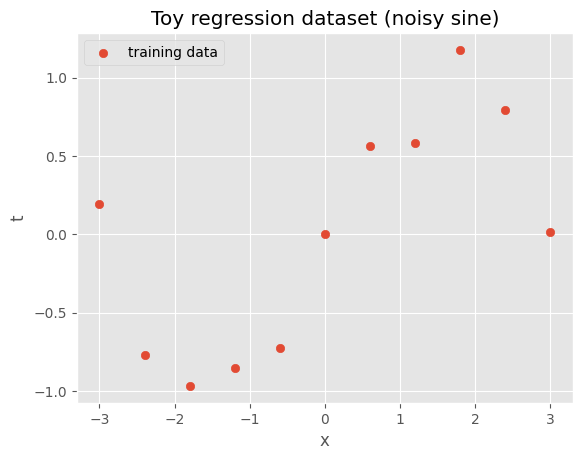

In [60]:
X, y = get_simple()
plt.scatter(X, y, label='training data')
plt.xlabel('x'); plt.ylabel('t')
plt.title('Toy regression dataset (noisy sine)')
plt.legend()
plt.show()

In [61]:
####################
# Your Code Here   #
####################
svr = SVR(kernel_func=RBFKernel(gamma=1.0), eps=0.2, C=1.0, random_state=42)
svr.fit(X[:, None], y)

X_test = np.linspace(-3, 3, 100)[:, None]
y_pred = svr.predict(X_test)
X_test = np.linspace(-3, 3, 100)
y_pred = svr.predict(X_test)

/Users/stars/Projects/University/PRML2/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/stars/Projects/University/PRML2/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [62]:
####################
# Your Code Here   #
####################

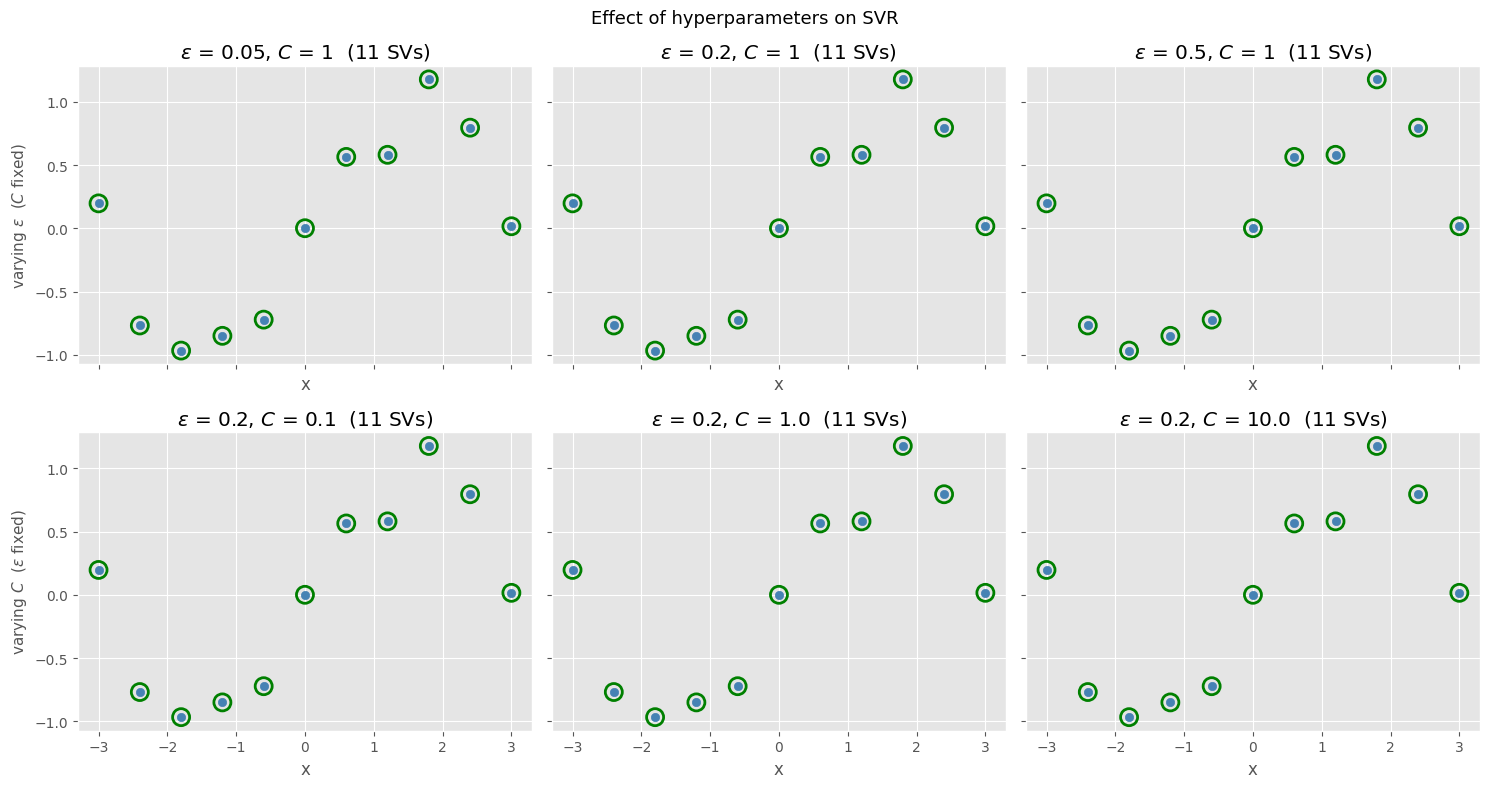

In [63]:
eps_values = [0.05, 0.2, 0.5]
C_values   = [0.1,  1.0, 10.0]
X_test = np.linspace(-3, 3, 200)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for i, eps in enumerate(eps_values):
    svr = SVR(kernel_func=RBFKernel(gamma=1.0), eps=eps, C=1.0, random_state=42)
    svr.fit(X, y)
    y_pred = svr.predict(X_test)
    ax = axes[0, i]
    ax.scatter(X, y, color='steelblue', zorder=3)
    ax.plot(X_test, y_pred, color='tomato')
    ax.fill_between(X_test, y_pred - eps, y_pred + eps, alpha=0.2, color='tomato')
    ax.scatter(svr.support_vectors_, svr.support_targets_, s=150,
               facecolors='none', edgecolors='green', linewidths=2, zorder=4)
    ax.set_title(rf'$\varepsilon$ = {eps}, $C$ = 1  ({len(svr.support_vectors_)} SVs)')

for i, C in enumerate(C_values):
    svr = SVR(kernel_func=RBFKernel(gamma=1.0), eps=0.2, C=C, random_state=42)
    svr.fit(X, y)
    y_pred = svr.predict(X_test)
    ax = axes[1, i]
    ax.scatter(X, y, color='steelblue', zorder=3)
    ax.plot(X_test, y_pred, color='tomato')
    ax.fill_between(X_test, y_pred - 0.2, y_pred + 0.2, alpha=0.2, color='tomato')
    ax.scatter(svr.support_vectors_, svr.support_targets_, s=150,
               facecolors='none', edgecolors='green', linewidths=2, zorder=4)
    ax.set_title(rf'$\varepsilon$ = 0.2, $C$ = {C}  ({len(svr.support_vectors_)} SVs)')

axes[0, 0].set_ylabel(r'varying $\varepsilon$  ($C$ fixed)', fontsize=11)
axes[1, 0].set_ylabel(r'varying $C$  ($\varepsilon$ fixed)', fontsize=11)
for ax in axes.flat:
    ax.set_xlabel('x')
plt.suptitle('Effect of hyperparameters on SVR', fontsize=13)
plt.tight_layout()
plt.show()